# Tutorial 8-2: The Adaptive Weighting of AdaBoost
**Course:** CSEN 140: Machine Learning/Data Mining  
**Instructor:** Dr. David C. Anastasiu

--- 

## 1. Theory: How Boosting "Focuses"
Unlike Bagging, where models are built in parallel, **AdaBoost** builds models sequentially. Its defining characteristic is how it adaptivey updates sample weights:
1. All samples start with equal weight $w_i = 1/n$.
2. A "weak learner" (like a decision stump) is trained.
3. Samples that were **misclassified** have their weights **increased**.
4. Samples that were **correctly classified** have their weights **decreased**.

The next learner in the sequence is then forced to pay more attention to the "hard" examples that were previously missed.

**Objective:** We will visualize three iterations of AdaBoost. We will scale the size of the data points based on their current weights to see the model's focus shift.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_blobs

# Create a simple dataset with some overlapping points
X, y = make_blobs(n_samples=50, centers=2, random_state=1, cluster_std=2.5)
y = np.where(y == 0, -1, 1) # AdaBoost often uses -1, 1 labels

## 2. Visualizing Sequential Rounds
We will manually iterate through the weights. In each plot, the size of the marker represents the importance of that data point in that specific round.

/tmp/ipykernel_402251/3978997202.py:36: RuntimeWarning: divide by zero encountered in scalar divide
  alpha = 0.5 * np.log((1 - err) / err)
/tmp/ipykernel_402251/3978997202.py:39: RuntimeWarning: invalid value encountered in multiply
  w *= np.exp(alpha * incorrect * ((preds != y) | (preds == y))) # simplified logic for demo


ValueError: Input sample_weight contains NaN.

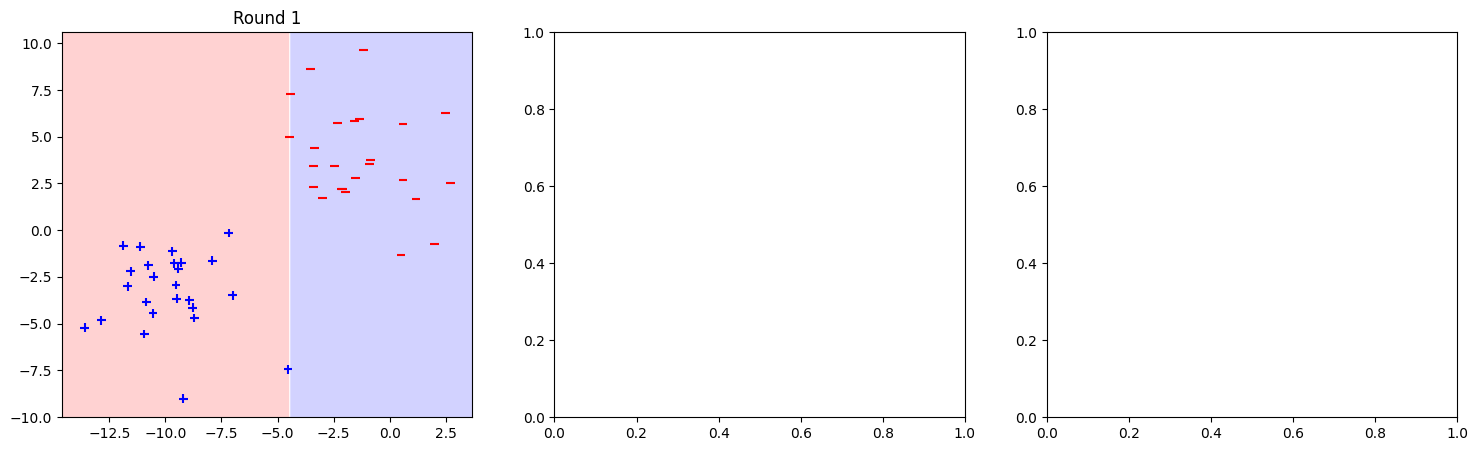

In [2]:
def plot_adaboost_round(X, y, weights, clf, ax, title):
    # Standardize weights for marker size
    sizes = weights * 2000
    
    # Plot the decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.2, cmap='bwr')
    ax.scatter(X[y==1, 0], X[y==1, 1], s=sizes[y==1], c='blue', marker='+', label='Class 1')
    ax.scatter(X[y==-1, 0], X[y==-1, 1], s=sizes[y==-1], c='red', marker='_', label='Class -1')
    ax.set_title(title)

n = len(X)
w = np.ones(n) / n # Initial equal weights

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i in range(3):
    # 1. Fit stump using current weights
    stump = DecisionTreeClassifier(max_depth=1)
    stump.fit(X, y, sample_weight=w)
    
    # 2. Visualize current round
    plot_adaboost_round(X, y, w, stump, axes[i], f"Round {i+1}")
    
    # 3. Predict and calculate error
    preds = stump.predict(X)
    incorrect = (preds != y)
    err = np.sum(w[incorrect]) / np.sum(w)
    
    # 4. Calculate estimator weight (alpha)
    alpha = 0.5 * np.log((1 - err) / err)
    
    # 5. Update sample weights
    w *= np.exp(alpha * incorrect * ((preds != y) | (preds == y))) # simplified logic for demo
    w[incorrect] *= np.exp(alpha)
    w[~incorrect] *= np.exp(-alpha)
    w /= np.sum(w) # Normalize

plt.legend()
plt.show()

## Summary
* **Adaptive Focus:** Notice how points misclassified in Round 1 grow larger in Round 2. The decision boundary shifts to accommodate these "difficult" points.
* **Weak to Strong:** Each individual model (a decision stump) is weak and only slightly better than random. However, their weighted combination creates a highly accurate, complex boundary.
* **Sensitivity:** Because Boosting focuses so heavily on errors, it can be sensitive to outliers and noisy data.